In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
df = pd.read_csv("Zomato Dataset.csv")


# Identifying datatypes 

In [19]:
df.dtypes

ID                             str
Delivery_person_ID             str
Delivery_person_Age        float64
Delivery_person_Ratings    float64
distance_km                float64
Order_Date                     str
Time_Orderd                float64
Time_Order_picked          float64
Weather_conditions             str
Road_traffic_density           str
Vehicle_condition            int64
Type_of_order                  str
Type_of_vehicle                str
multiple_deliveries        float64
Festival                       str
City                           str
Time_taken (min)             int64
dtype: object

In [20]:
df = df.rename(columns = {"Time_Orderd":"Time_Ordered"})

# Standardizing the columns

In [21]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
    .str.replace("(","", regex=False)
    .str.replace(")","", regex=False))

In [22]:
df

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,distance_km,order_date,time_ordered,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min
0,0xcdcd,DEHRES17DEL01,36.0,4.2,10.28,12-02-2022,21.55,22.10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,6.24,13-02-2022,14.55,15.05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,13.79,04-03-2022,17.30,17.40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,2.93,13-02-2022,9.20,9.30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,19.40,14-02-2022,19.50,20.05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45579,0x7c09,JAPRES04DEL01,30.0,4.8,1.49,24-03-2022,11.35,11.45,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32
45580,0xd641,AGRRES16DEL01,21.0,4.6,11.01,16-02-2022,19.55,20.10,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36
45581,0x4f8d,CHENRES08DEL03,30.0,4.9,4.66,11-03-2022,23.50,0.05,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16
45582,0x5eee,COIMBRES11DEL01,20.0,4.7,6.23,07-03-2022,13.35,13.40,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26


# Standardizing values

In [23]:
df["type_of_vehicle"] = df["type_of_vehicle"].str.title()
df

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,distance_km,order_date,time_ordered,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min
0,0xcdcd,DEHRES17DEL01,36.0,4.2,10.28,12-02-2022,21.55,22.10,Fog,Jam,2,Snack,Motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,6.24,13-02-2022,14.55,15.05,Stormy,High,1,Meal,Motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,13.79,04-03-2022,17.30,17.40,Sandstorms,Medium,1,Drinks,Scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,2.93,13-02-2022,9.20,9.30,Sandstorms,Low,0,Buffet,Motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,19.40,14-02-2022,19.50,20.05,Fog,Jam,1,Snack,Scooter,1.0,No,Metropolitian,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45579,0x7c09,JAPRES04DEL01,30.0,4.8,1.49,24-03-2022,11.35,11.45,Windy,High,1,Meal,Motorcycle,0.0,No,Metropolitian,32
45580,0xd641,AGRRES16DEL01,21.0,4.6,11.01,16-02-2022,19.55,20.10,Windy,Jam,0,Buffet,Motorcycle,1.0,No,Metropolitian,36
45581,0x4f8d,CHENRES08DEL03,30.0,4.9,4.66,11-03-2022,23.50,0.05,Cloudy,Low,1,Drinks,Scooter,0.0,No,Metropolitian,16
45582,0x5eee,COIMBRES11DEL01,20.0,4.7,6.23,07-03-2022,13.35,13.40,Cloudy,High,0,Snack,Motorcycle,1.0,No,Metropolitian,26


# Converting dtypes

In [25]:
df["order_date"] = pd.to_datetime(df["order_date"],errors = "coerce",format = '%d-%m-%Y')

In [26]:
df["multiple_deliveries"] = pd.to_numeric(df["multiple_deliveries"],errors ="coerce")

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       45584 non-null  str           
 1   delivery_person_id       45584 non-null  str           
 2   delivery_person_age      43730 non-null  float64       
 3   delivery_person_ratings  43676 non-null  float64       
 4   distance_km              45584 non-null  float64       
 5   order_date               45584 non-null  datetime64[us]
 6   time_ordered             43853 non-null  float64       
 7   time_order_picked        45584 non-null  float64       
 8   weather_conditions       44968 non-null  str           
 9   road_traffic_density     44983 non-null  str           
 10  vehicle_condition        45584 non-null  int64         
 11  type_of_order            45584 non-null  str           
 12  type_of_vehicle          45584 non-null  st

# finding unusual data

In [29]:
df.isna().sum()

id                            0
delivery_person_id            0
delivery_person_age        1854
delivery_person_ratings    1908
distance_km                   0
order_date                    0
time_ordered               1731
time_order_picked             0
weather_conditions          616
road_traffic_density        601
vehicle_condition             0
type_of_order                 0
type_of_vehicle               0
multiple_deliveries         993
festival                    228
city                       1200
time_taken_min                0
dtype: int64

In [30]:
df["delivery_person_ratings"].unique()

array([4.2, 4.7, 4.3, 4.5, 4. , 4.9, 4.1, 5. , 4.8, 3.5, 4.6, nan, 4.4,
       3.8, 3.9, 3.7, 2.6, 2.5, 3.6, 3.1, 2.7, 1. , 3.2, 3.3, 6. , 3.4,
       2.8, 2.9, 3. ])

In [31]:
df[df["delivery_person_ratings"]>5]

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,distance_km,order_date,time_ordered,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min
3577,0x46d,BANGRES05DEL01,50.0,6.0,6.21,2022-03-13,NaN,12.30,NaN,NaN,3,Meal,Electric_Scooter,0.0,No,Urban,25
4705,0x493,HYDRES17DEL01,50.0,6.0,16.90,2022-04-04,NaN,23.20,NaN,NaN,3,Snack,Bicycle,0.0,No,Metropolitian,27
5160,0x4f2,JAPRES08DEL01,50.0,6.0,16.38,2022-03-18,NaN,18.50,NaN,NaN,3,Drinks,Scooter,1.0,No,Metropolitian,20
5353,0x430,BANGRES19DEL01,50.0,6.0,17.08,2022-04-06,NaN,20.55,NaN,NaN,3,Meal,Electric_Scooter,1.0,No,Metropolitian,18
5642,0xbef1,AGRRES13DEL02,50.0,6.0,7.44,2022-02-13,NaN,18.05,NaN,NaN,3,Drinks,Scooter,1.0,No,Metropolitian,20
6385,0x427,JAPRES06DEL02,50.0,6.0,19.36,2022-04-02,NaN,22.10,NaN,NaN,3,Meal,Electric_Scooter,0.0,No,Urban,20
7022,0x3eb,MYSRES15DEL02,50.0,6.0,3.11,2022-03-15,NaN,0.25,NaN,NaN,3,Buffet,Scooter,1.0,No,Metropolitian,14
7672,0xd42,VADRES09DEL01,50.0,6.0,1.57,2022-03-21,NaN,8.35,NaN,NaN,3,Meal,Bicycle,1.0,No,Metropolitian,22
9490,0x3f0,BANGRES010DEL01,50.0,6.0,10.87,2022-03-12,NaN,18.25,NaN,NaN,3,Drinks,Scooter,1.0,No,Urban,17
9526,0x3ef,RANCHIRES13DEL01,50.0,6.0,10.56,2022-03-20,NaN,17.55,NaN,NaN,3,Snack,Bicycle,1.0,No,Metropolitian,32


In [32]:
df[df["delivery_person_age"]<18]

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,distance_km,order_date,time_ordered,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min
2378,0x564,JAPRES15DEL03,15.0,1.0,13.41,2022-03-12,NaN,17.20,NaN,NaN,3,Meal,Motorcycle,0.0,No,Urban,15
2896,0xcd0,INDORES010DEL03,15.0,1.0,9.07,2022-04-03,NaN,20.30,NaN,NaN,3,Snack,Scooter,1.0,No,Metropolitian,29
2942,0x91a,SURRES17DEL03,15.0,1.0,9.12,2022-03-21,NaN,22.10,NaN,NaN,3,Buffet,Bicycle,1.0,No,Metropolitian,20
5893,0x474,CHENRES15DEL03,15.0,1.0,4.66,2022-03-11,NaN,20.50,NaN,NaN,3,Drinks,Bicycle,1.0,No,Metropolitian,25
9147,0x73f,BANGRES05DEL01,15.0,1.0,17.08,2022-03-25,NaN,23.25,NaN,NaN,3,Buffet,Motorcycle,2.0,No,Metropolitian,34
10891,0x1b49,MUMRES14DEL02,15.0,1.0,7.65,2022-03-30,NaN,20.55,NaN,NaN,3,Buffet,Motorcycle,1.0,No,Metropolitian,39
11116,0x40b,SURRES12DEL01,15.0,1.0,1.52,2022-03-05,NaN,11.30,NaN,NaN,3,Meal,Scooter,1.0,No,Urban,27
12084,0x523,INDORES03DEL02,15.0,1.0,7.56,2022-03-24,NaN,21.15,NaN,NaN,3,Buffet,Bicycle,0.0,No,Metropolitian,28
15115,0x18b0,RANCHIRES02DEL01,15.0,1.0,11.01,2022-03-16,NaN,23.55,NaN,NaN,3,Meal,Bicycle,1.0,No,Metropolitian,21
15918,0x550,CHENRES08DEL02,15.0,1.0,7.76,2022-03-11,NaN,18.10,NaN,NaN,3,Snack,Bicycle,0.0,No,Metropolitian,17


In [33]:
df[(df["delivery_person_age"]<18) | (df["delivery_person_age"]>40)]

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,distance_km,order_date,time_ordered,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min
2378,0x564,JAPRES15DEL03,15.0,1.0,13.41,2022-03-12,NaN,17.20,NaN,NaN,3,Meal,Motorcycle,0.0,No,Urban,15
2896,0xcd0,INDORES010DEL03,15.0,1.0,9.07,2022-04-03,NaN,20.30,NaN,NaN,3,Snack,Scooter,1.0,No,Metropolitian,29
2942,0x91a,SURRES17DEL03,15.0,1.0,9.12,2022-03-21,NaN,22.10,NaN,NaN,3,Buffet,Bicycle,1.0,No,Metropolitian,20
3577,0x46d,BANGRES05DEL01,50.0,6.0,6.21,2022-03-13,NaN,12.30,NaN,NaN,3,Meal,Electric_Scooter,0.0,No,Urban,25
4705,0x493,HYDRES17DEL01,50.0,6.0,16.90,2022-04-04,NaN,23.20,NaN,NaN,3,Snack,Bicycle,0.0,No,Metropolitian,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42063,0x5fc,INDORES11DEL03,50.0,6.0,4.54,2022-03-17,NaN,20.40,NaN,NaN,3,Buffet,Scooter,0.0,No,Metropolitian,28
42826,0x53e,BANGRES12DEL01,50.0,6.0,1.55,2022-03-19,NaN,9.40,NaN,NaN,3,Drinks,Electric_Scooter,1.0,No,Metropolitian,19
44394,0x2314,VADRES04DEL01,15.0,1.0,11.01,2022-03-14,NaN,17.40,NaN,NaN,3,Drinks,Scooter,0.0,No,Metropolitian,34
44872,0x8d4,CHENRES02DEL02,15.0,1.0,20.18,2022-03-18,NaN,0.45,NaN,NaN,3,Snack,Electric_Scooter,1.0,No,Urban,26


In [34]:
pd.crosstab(
    df["delivery_person_age"],
    df["delivery_person_ratings"]
)

delivery_person_ratings,1.0,2.5,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,...,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0,6.0
delivery_person_age,,,,,,,,,,,,,,,,,,,,,
15.0,38,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20.0,0,2,4,2,2,1,0,3,5,0,...,45,32,36,165,342,388,382,405,216,0
21.0,0,3,5,2,2,2,0,3,0,0,...,39,37,37,189,370,406,396,348,228,0
22.0,0,1,3,3,1,2,0,6,1,4,...,50,59,38,176,398,383,392,385,200,0
23.0,0,4,1,1,1,1,0,2,2,3,...,33,38,42,159,357,387,377,391,193,0
24.0,0,0,3,1,3,2,0,1,6,2,...,51,47,55,198,387,394,389,373,206,0
25.0,0,2,1,3,2,5,0,3,1,0,...,57,43,41,193,388,384,357,383,212,0
26.0,0,1,0,3,3,1,0,1,2,2,...,55,41,50,178,359,399,382,380,198,0
27.0,0,2,0,3,1,2,0,1,1,1,...,51,39,51,195,410,364,362,359,209,0


**Data Quality Observation Delivery Person Age & Rating**

**During the data-quality analysis, an unusual pattern was identified in the delivery_person_age and delivery_person_ratings variables. The rating variable contains values as high as 6, which appears unusual given the expected rating scale.**

**Further investigation was performed by filtering delivery personnel with ages below 18 and above 40. This revealed 91 records containing the ages 15 and 50.**

**A consistent pattern was observed within these records: delivery personnel aged 15 were associated with a rating of 1, while those aged 50 were associated with a rating of 6.**

**This pattern suggests a potential data-quality or data-generation issue and requires further investigation before deciding whether these observations should be corrected, retained, or treated as missing values.**

In [38]:
df.drop(df[(df["delivery_person_age"]<18) | (df["delivery_person_age"]>40)].index,inplace = True)

**91 records were identified with anomalous age/rating combinations. Because the observed values violated the expected business constraints, these records were treated as invalid observations.**

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 45493 entries, 0 to 45583
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       45493 non-null  str           
 1   delivery_person_id       45493 non-null  str           
 2   delivery_person_age      43639 non-null  float64       
 3   delivery_person_ratings  43585 non-null  float64       
 4   distance_km              45493 non-null  float64       
 5   order_date               45493 non-null  datetime64[us]
 6   time_ordered             43853 non-null  float64       
 7   time_order_picked        45493 non-null  float64       
 8   weather_conditions       44968 non-null  str           
 9   road_traffic_density     44983 non-null  str           
 10  vehicle_condition        45493 non-null  int64         
 11  type_of_order            45493 non-null  str           
 12  type_of_vehicle          45493 non-null  str    

In [40]:
df["delivery_person_ratings"].value_counts().sort_index()

delivery_person_ratings
2.5      20
2.6      22
2.7      22
2.8      19
2.9      19
3.0       6
3.1      29
3.2      29
3.3      25
3.4      32
3.5     249
3.6     207
3.7     225
3.8     228
3.9     197
4.0    1077
4.1    1430
4.2    1418
4.3    1409
4.4    1360
4.5    3302
4.6    6938
4.7    7140
4.8    7146
4.9    7040
5.0    3996
Name: count, dtype: int64

**handing missing values**

In [41]:
df.isna().sum()

id                            0
delivery_person_id            0
delivery_person_age        1854
delivery_person_ratings    1908
distance_km                   0
order_date                    0
time_ordered               1640
time_order_picked             0
weather_conditions          525
road_traffic_density        510
vehicle_condition             0
type_of_order                 0
type_of_vehicle               0
multiple_deliveries         993
festival                    228
city                       1198
time_taken_min                0
dtype: int64

<Axes: xlabel='delivery_person_ratings', ylabel='Count'>

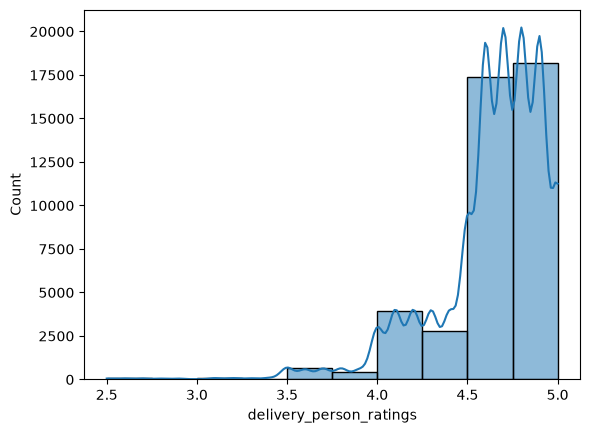

In [42]:
sns.histplot(df["delivery_person_ratings"],kde = True,bins =  10)

**since the rating is skewed left median is choosen to fillna, filled 1908 nulls with median**

In [43]:
df["delivery_person_ratings"]=df["delivery_person_ratings"].fillna(df["delivery_person_ratings"].median())

<Axes: xlabel='delivery_person_age', ylabel='Count'>

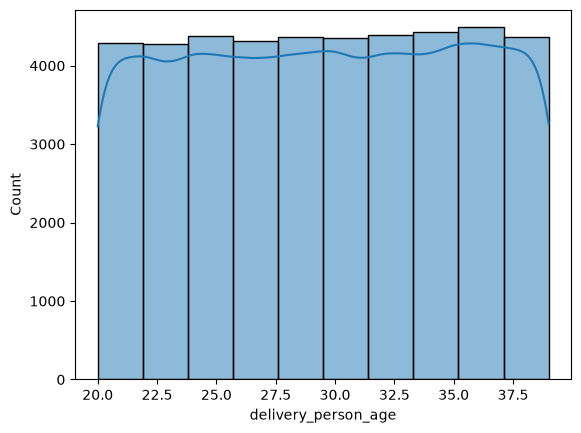

In [44]:
sns.histplot(df["delivery_person_age"],kde = True,bins = 10)

**since the distribution is uniform we can either use mean or median, here i have choosen mean to fill the mean. Filled 1854 nulls with mean**

In [45]:
df["delivery_person_age"]=df["delivery_person_age"].fillna(df["delivery_person_age"].mean())

In [46]:
df.isna().sum()

id                            0
delivery_person_id            0
delivery_person_age           0
delivery_person_ratings       0
distance_km                   0
order_date                    0
time_ordered               1640
time_order_picked             0
weather_conditions          525
road_traffic_density        510
vehicle_condition             0
type_of_order                 0
type_of_vehicle               0
multiple_deliveries         993
festival                    228
city                       1198
time_taken_min                0
dtype: int64

In [47]:
df["weather_conditions"].unique()

<ArrowStringArray>
['Fog', 'Stormy', 'Sandstorms', 'Windy', 'Cloudy', 'Sunny', nan]
Length: 7, dtype: str

In [48]:
df["weather_conditions"].value_counts(normalize=True, dropna=False) * 100

weather_conditions
Fog           16.822368
Stormy        16.670697
Cloudy        16.558591
Sandstorms    16.472864
Windy         16.314598
Sunny         16.006858
NaN            1.154024
Name: proportion, dtype: float64

**Weather conditions contained 525 missing observations (1.15% of the dataset). Since weather is a categorical variable and the missing values could not be reliably inferred from the available data, they were categorized as Unknown rather than imputed using the mode. This prevents artificially increasing the frequency of any existing weather category.**

In [49]:
df["weather_conditions"] = df["weather_conditions"].fillna("Unknown")

In [50]:
df["road_traffic_density"].unique()

<ArrowStringArray>
['Jam', 'High', 'Medium', 'Low', nan]
Length: 5, dtype: str

In [51]:
df["road_traffic_density"].value_counts(normalize=True, dropna=False) * 100

road_traffic_density
Low       34.018420
Jam       31.079507
Medium    24.058646
High       9.722375
NaN        1.121052
Name: proportion, dtype: float64

**Similar case as road_traffic_density**

In [52]:
df["road_traffic_density"] = df["road_traffic_density"].fillna("Unknown")

In [53]:
df.isna().sum()

id                            0
delivery_person_id            0
delivery_person_age           0
delivery_person_ratings       0
distance_km                   0
order_date                    0
time_ordered               1640
time_order_picked             0
weather_conditions            0
road_traffic_density          0
vehicle_condition             0
type_of_order                 0
type_of_vehicle               0
multiple_deliveries         993
festival                    228
city                       1198
time_taken_min                0
dtype: int64

In [54]:
df["multiple_deliveries"].unique()

array([ 3.,  1.,  0., nan,  2.])

In [55]:
df["multiple_deliveries"].value_counts(normalize=True, dropna=False) * 100

multiple_deliveries
1.0    61.769943
0.0    30.897061
2.0     4.356714
NaN     2.182753
3.0     0.793529
Name: proportion, dtype: float64

In [56]:
df[df["multiple_deliveries"].isna()]["time_taken_min"].describe()

count    993.000000
mean      22.767372
std        8.714170
min       10.000000
25%       16.000000
50%       21.000000
75%       28.000000
max       54.000000
Name: time_taken_min, dtype: float64

In [57]:
df[df["multiple_deliveries"].notna()]["time_taken_min"].describe()

count    44500.000000
mean        26.375708
std          9.386339
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: time_taken_min, dtype: float64

**multiple_deliveries contains 993 missing observations (2.18%). Since the meaning of the missing values cannot be reliably determined from the available data, they were retained as NaN rather than assigning an arbitrary value. Although a difference in delivery time was observed between missing and non-missing groups, this does not establish the reason for the missingness. Therefore, no imputation was performed.**

In [58]:
df["festival"].unique()

<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [59]:
df["festival"].value_counts(normalize=True, dropna=False) * 100

festival
No     97.533687
Yes     1.965137
NaN     0.501176
Name: proportion, dtype: float64

**festival contained 228 missing observations (0.50%). Since missing values could not be confidently interpreted as either a festival or non-festival day, they were categorized as Unknown. This preserves the distinction between explicitly recorded No values and unavailable information.**

In [60]:
df["festival"] = df["festival"].fillna("Unknown")

In [63]:
df["city"].value_counts(normalize=True, dropna=False) * 100

city
Metropolitian    74.787330
Urban            22.218803
NaN               2.633372
Semi-Urban        0.360495
Name: proportion, dtype: float64

**The city variable contained 2.63% missing observations. Since the missing city category could not be reliably inferred from the available information, the missing values were categorized as Unknown rather than being assigned the most frequent category. This prevents introducing bias into subsequent city-level analysis.**

In [64]:
df['city'] = df['city'].fillna("Unknown")

In [66]:
df.head(50)

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,distance_km,order_date,time_ordered,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min
0,0xcdcd,DEHRES17DEL01,36.000000,4.2,10.28,2022-02-12,21.55,22.10,Fog,Jam,2,Snack,Motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.000000,4.7,6.24,2022-02-13,14.55,15.05,Stormy,High,1,Meal,Motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.000000,4.7,13.79,2022-03-04,17.30,17.40,Sandstorms,Medium,1,Drinks,Scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.000000,4.3,2.93,2022-02-13,9.20,9.30,Sandstorms,Low,0,Buffet,Motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.000000,4.7,19.40,2022-02-14,19.50,20.05,Fog,Jam,1,Snack,Scooter,1.0,No,Metropolitian,41
5,0x3af3,MUMRES15DEL03,29.000000,4.5,13.76,2022-04-02,20.25,20.35,Sandstorms,Jam,2,Buffet,Electric_Scooter,1.0,No,Metropolitian,20
6,0x3aab,MYSRES01DEL01,35.000000,4.0,6.22,2022-03-01,14.55,15.10,Windy,High,1,Meal,Scooter,1.0,No,Metropolitian,33
7,0x689b,PUNERES20DEL01,33.000000,4.2,16.85,2022-03-16,20.30,20.40,Sandstorms,Jam,2,Snack,Motorcycle,1.0,No,Metropolitian,40
8,0x6f67,HYDRES14DEL01,34.000000,4.9,10.76,2022-03-20,20.40,20.50,Cloudy,Jam,0,Snack,Motorcycle,NaN,No,Metropolitian,41
9,0xc9cf,KOLRES15DEL03,21.000000,4.7,4.54,2022-02-15,21.15,21.30,Windy,Jam,0,Meal,Motorcycle,1.0,No,Urban,15


In [67]:
df.info()

<class 'pandas.DataFrame'>
Index: 45493 entries, 0 to 45583
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       45493 non-null  str           
 1   delivery_person_id       45493 non-null  str           
 2   delivery_person_age      45493 non-null  float64       
 3   delivery_person_ratings  45493 non-null  float64       
 4   distance_km              45493 non-null  float64       
 5   order_date               45493 non-null  datetime64[us]
 6   time_ordered             43853 non-null  float64       
 7   time_order_picked        45493 non-null  float64       
 8   weather_conditions       45493 non-null  str           
 9   road_traffic_density     45493 non-null  str           
 10  vehicle_condition        45493 non-null  int64         
 11  type_of_order            45493 non-null  str           
 12  type_of_vehicle          45493 non-null  str    

**dtypes_changed is order_date and multiple_deliveries**

In [68]:
df.to_csv("cleaned_zomato.csv",index = False)